# Classification de radios thoraciques — CNN entraîné de zéro

Dans ce notebook, on construit un réseau de neurones convolutif (CNN) **entièrement à la main** pour classer des radios des poumons en trois catégories : `NORMAL`, `PNEUMONIA_bacterial` (pneumonie bactérienne) et `PNEUMONIA_viral` (pneumonie virale).

L'idée du projet est de comparer deux approches sur le même problème :
- **ici** : un CNN qu'on entraîne de zéro, donc le modèle part de poids aléatoires et apprend tout par lui-même ;
- dans l'autre notebook : du **transfert learning** avec ResNet50, un réseau déjà pré-entraîné sur des millions d'images.

Les deux notebooks suivent volontairement les mêmes grandes étapes (préparation des données, augmentation, entraînement, évaluation) pour que la comparaison soit la plus juste possible.

## 1. Imports

On importe les librairies nécessaires : TensorFlow/Keras pour le modèle, NumPy et pandas pour manipuler les données, matplotlib et seaborn pour les graphiques, et plusieurs outils de scikit-learn pour découper le jeu de données, calculer les poids de classes et mesurer les performances (matrice de confusion, ROC, etc.).

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

## 2. Configuration générale

On fixe ici les paramètres de base : la taille des images (224×224 pixels), la taille des batchs (32 images traitées à la fois), le chemin vers le dossier des données et la liste des trois classes. Le dictionnaire `CLASS_TO_INDEX` associe chaque nom de classe à un numéro (0, 1, 2), car le modèle travaille avec des chiffres et pas avec du texte.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
DATA_ROOT = Path("../data/chest_Xray")
CLASS_NAMES = ['NORMAL', 'PNEUMONIA_bacterial', 'PNEUMONIA_viral']
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

## 3. Préparation des données : étiquetage et découpage

Les images de pneumonie sont rangées dans un seul dossier `PNEUMONIA`, mais on veut distinguer les cas bactériens et viraux. La fonction `label_from_path` regarde le nom du fichier (qui contient `bacteria` ou `virus`) pour retrouver la bonne classe.

Ensuite, `build_split_dataframe` parcourt les dossiers et range tout dans un tableau pandas (chemin, classe, numéro de classe). On fusionne les images `train` et `val` d'origine, puis on refait nous-mêmes un découpage 80 % entraînement / 20 % validation. Le `stratify` garde les mêmes proportions de classes dans chaque morceau, et `random_state=42` rend le découpage reproductible.

In [3]:
def label_from_path(path):
    name = Path(path).name.lower()
    if '_bacteria_' in name:
        return 'PNEUMONIA_bacterial'
    if '_virus_' in name:
        return 'PNEUMONIA_viral'
    return 'NORMAL'


def build_split_dataframe(split_name):
    records = []
    for class_name in ['NORMAL', 'PNEUMONIA']:
        folder = DATA_ROOT / split_name / class_name
        for file_path in folder.glob('*.jpeg'):
            label = label_from_path(file_path)
            records.append({
                'filepath': str(file_path),
                'label': label,
                'label_index': CLASS_TO_INDEX[label],
            })
    return pd.DataFrame(records)


train_df_raw = build_split_dataframe('train')
val_df_raw = build_split_dataframe('val')
test_df = build_split_dataframe('test')

train_val_df = pd.concat([train_df_raw, val_df_raw], ignore_index=True)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    stratify=train_val_df['label_index'],
    random_state=42,
)

print('Répartition après fusion train + val :')
print(train_val_df['label'].value_counts().reindex(CLASS_NAMES))
print('\nRépartition train / val :')
print(train_df['label'].value_counts().reindex(CLASS_NAMES))
print(val_df['label'].value_counts().reindex(CLASS_NAMES))
print('\nRépartition test :')
print(test_df['label'].value_counts().reindex(CLASS_NAMES))

Répartition après fusion train + val :
label
NORMAL                 1349
PNEUMONIA_bacterial    2538
PNEUMONIA_viral        1345
Name: count, dtype: int64

Répartition train / val :
label
NORMAL                 1079
PNEUMONIA_bacterial    2030
PNEUMONIA_viral        1076
Name: count, dtype: int64
label
NORMAL                 270
PNEUMONIA_bacterial    508
PNEUMONIA_viral        269
Name: count, dtype: int64

Répartition test :
label
NORMAL                 234
PNEUMONIA_bacterial    242
PNEUMONIA_viral        148
Name: count, dtype: int64


## 4. Exploration : répartition des classes

On affiche le nombre d'images par classe dans le jeu d'entraînement, en texte et en diagramme en barres. Ça permet de voir tout de suite que le dataset est **déséquilibré** (beaucoup plus de cas de pneumonie que de cas normaux). C'est important, car un déséquilibre peut pousser le modèle à favoriser la classe la plus fréquente.

Répartition des classes (Normal, Bactérienne, Virale) : [1079 2030 1076]


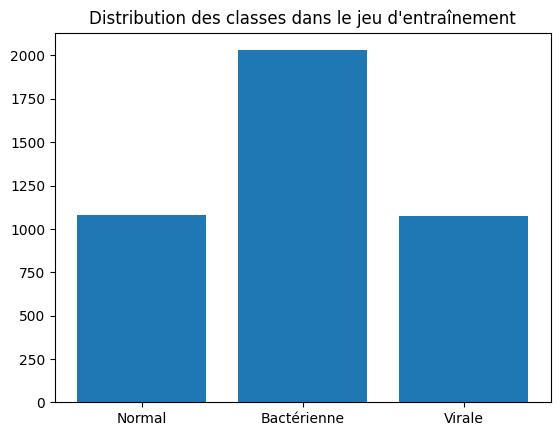

In [4]:
# Répartition des classes dans le train
class_counts = train_df['label'].value_counts().reindex(CLASS_NAMES).fillna(0).to_numpy()
print('Répartition des classes (Normal, Bactérienne, Virale) :', class_counts)
plt.bar(['Normal', 'Bactérienne', 'Virale'], class_counts)
plt.title('Distribution des classes dans le jeu d\'entraînement')
plt.show()

## 5. Gestion du déséquilibre : poids de classes

Pour corriger le déséquilibre repéré juste avant, on calcule des **poids de classes** avec `compute_class_weight(..., 'balanced')`. Les classes rares reçoivent un poids plus élevé : le modèle est donc « plus puni » quand il se trompe sur une classe peu représentée. Ça l'oblige à faire attention à toutes les classes et pas seulement à la majoritaire.

In [5]:
# Poids de classe équilibrés
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label_index'].to_numpy(),
)
class_weight = {idx: weight for idx, weight in enumerate(class_weight_values)}
print('class_weight utilisé :', class_weight)

class_weight utilisé : {0: np.float64(1.2928637627432809), 1: np.float64(0.687192118226601), 2: np.float64(1.296468401486989)}


## 6. Pipeline tf.data et data augmentation

On crée ici les jeux de données prêts pour le modèle :
- `load_image` lit chaque image, la décode, la redimensionne en 224×224 et la convertit en nombres décimaux.
- `make_dataset` transforme un tableau pandas en `tf.data.Dataset`, mélange les données (pour le train) et les regroupe en batchs.

On ajoute ensuite de la **data augmentation** (retournement horizontal, petite rotation, zoom, contraste) appliquée uniquement au train. Le but est de montrer au modèle des versions légèrement modifiées des images à chaque epoch, pour qu'il généralise mieux et n'apprenne pas « par cœur ». Le `prefetch` prépare les batchs à l'avance pour aller plus vite.

In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int32)


def make_dataset(frame, shuffle=False):
    paths = frame['filepath'].to_numpy()
    labels = frame['label_index'].to_numpy()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(frame), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    return ds


AUTOTUNE = tf.data.AUTOTUNE
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

train_ds_augmented = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds_augmented = train_ds_augmented.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# CNN plus costaud (4 blocs convolutionnels)
Version 3 classes : NORMAL / PNEUMONIA_bacterial / PNEUMONIA_viral.

## 7. Architecture du CNN (construit de zéro)

C'est la grosse différence avec le notebook ResNet50 : ici on définit **nous-mêmes** toute l'architecture, et le modèle part de zéro (poids aléatoires).

Le réseau est une pile de 4 blocs convolutifs. Chaque bloc applique des `Conv2D` (qui détectent des motifs dans l'image : bords, textures, formes…), une `BatchNormalization` (qui stabilise l'entraînement), une activation `ReLU` et un `MaxPooling2D` (qui réduit la taille de l'image en gardant l'essentiel). Plus on avance, plus le nombre de filtres augmente (32 → 64 → 128 → 256), donc le réseau apprend des motifs de plus en plus complexes.

À la fin, le `GlobalAveragePooling2D` résume tout, une couche `Dense` fait le tri, le `Dropout(0.5)` éteint la moitié des neurones au hasard pendant l'entraînement (contre le surapprentissage), et la dernière couche `Dense` + `softmax` sort les probabilités des 3 classes. La régularisation `l2` ajoute une petite pénalité pour éviter des poids trop grands.

In [7]:
from tensorflow.keras import layers, regularizers

l2_reg = regularizers.l2(1e-4)

model = tf.keras.Sequential([
    # Prétraitement
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloc 1
    layers.Conv2D(32, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    # Bloc 2
    layers.Conv2D(64, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    # Bloc 3
    layers.Conv2D(128, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(128, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    # Bloc 4
    layers.Conv2D(256, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(256, 3, padding='same', activation=None, kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    # Tête de classification
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=l2_reg),
    layers.Dropout(0.5),
    layers.Dense(len(CLASS_NAMES), activation='softmax'),
])

model.summary()

c:\Users\mmn\anaconda3\envs\zoidberg\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 28, 28, 256)    │             

 Total params: 1,233,283 (4.70 MB)

 Trainable params: 1,231,427 (4.70 MB)

 Non-trainable params: 1,856 (7.25 KB)

## 8. Compilation

On configure l'entraînement : l'optimiseur `Adam` (learning rate de 0.0001) qui ajuste les poids, la fonction de perte `sparse_categorical_crossentropy` adaptée à une classification multi-classes avec labels en entiers, et les métriques suivies (accuracy, et top-2 accuracy qui regarde si la bonne classe est dans les 2 meilleures prédictions).

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy'),
    ],
)

## 9. Validation croisée (5-fold)

Avant l'entraînement final, on fait une **validation croisée** pour vérifier que le modèle est stable et pas juste chanceux sur un découpage précis. On coupe le train en 5 morceaux (folds) : à chaque tour, 4 servent à entraîner et 1 à valider, et on tourne. On recrée un modèle neuf à chaque fold (`clone_model`) pour repartir de zéro. À la fin, on regarde la moyenne des scores : si elle est régulière entre les folds, c'est bon signe.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label_index']), start=1):
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)

    fold_train_ds = make_dataset(fold_train_df, shuffle=True)
    fold_val_ds = make_dataset(fold_val_df)
    fold_train_ds_augmented = fold_train_ds.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)

    fold_class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(CLASS_NAMES)),
        y=fold_train_df['label_index'].to_numpy(),
    )
    fold_class_weight = {idx: weight for idx, weight in enumerate(fold_class_weights)}

    fold_model = tf.keras.models.clone_model(model)
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy'),
        ],
    )

    fold_history = fold_model.fit(
        fold_train_ds_augmented,
        validation_data=fold_val_ds,
        epochs=10,
        class_weight=fold_class_weight,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                mode='max',
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )
        ],
        verbose=0,
    )

    fold_loss, fold_acc, fold_top2 = fold_model.evaluate(fold_val_ds, verbose=0)
    cv_scores.append({'fold': fold, 'loss': fold_loss, 'accuracy': fold_acc, 'top2_accuracy': fold_top2})
    print(f'Fold {fold} - loss: {fold_loss:.4f} - accuracy: {fold_acc:.4f} - top2_accuracy: {fold_top2:.4f}')

cv_scores = pd.DataFrame(cv_scores)
print('\nMoyennes CV :')
print(cv_scores[['loss', 'accuracy', 'top2_accuracy']].mean())

Fold 1 - loss: 0.6764 - accuracy: 0.7300 - top2_accuracy: 0.9654
Fold 2 - loss: 1.6094 - accuracy: 0.4851 - top2_accuracy: 0.7419
Fold 3 - loss: 0.7363 - accuracy: 0.7264 - top2_accuracy: 0.9558
Fold 4 - loss: 1.9127 - accuracy: 0.4851 - top2_accuracy: 0.7419
Fold 5 - loss: 0.6843 - accuracy: 0.7348 - top2_accuracy: 0.9654

Moyennes CV :
loss             1.123827
accuracy         0.632258
top2_accuracy    0.874074
dtype: float64


## 10. Callbacks d'entraînement

Les callbacks sont des « surveillants » qui agissent pendant l'entraînement :
- `EarlyStopping` arrête l'entraînement si l'accuracy de validation ne progresse plus pendant 5 epochs, et garde les meilleurs poids (pour ne pas continuer à apprendre dans le vide et surapprendre).
- `ReduceLROnPlateau` diminue le learning rate quand le modèle stagne, pour qu'il affine ses poids plus finement au lieu de tourner en rond.

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max', 
        patience=5, 
        min_delta=3e-4,
        restore_best_weights=True, 
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', 
        mode='max', 
        factor=0.5, 
        patience=2,
        min_lr=1e-6, 
        verbose=1
    ),
]

## 11. Entraînement du modèle final

On lance l'entraînement sur 40 epochs maximum (l'`EarlyStopping` coupera sans doute avant). On passe les données augmentées, les poids de classes calculés plus tôt et le jeu de validation pour suivre les performances au fil des epochs.

In [11]:
history = model.fit(
    train_ds_augmented,
    class_weight=class_weight,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
)

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.6189 - loss: 0.8802 - top2_accuracy: 0.9145 - val_accuracy: 0.4852 - val_loss: 1.6880 - val_top2_accuracy: 0.7421 - learning_rate: 1.0000e-04
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6951 - loss: 0.7402 - top2_accuracy: 0.9527 - val_accuracy: 0.4852 - val_loss: 1.8664 - val_top2_accuracy: 0.7421 - learning_rate: 1.0000e-04
Epoch 3/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.7036 - loss: 0.7201 - top2_accuracy: 0.9501 
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
131/131 ━━━━━━━━━━━━━━━━━━━━ 2907s 22s/step - accuracy: 0.7135 - loss: 0.7067 - top2_accuracy: 0.9532 - val_accuracy: 0.4852 - val_loss: 1.8490 - val_top2_accuracy: 0.7421 - learning_rate: 1.0000e-04
Epoch 4/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.7410 - loss: 0.6671 - top2_accuracy: 0.9589 - val_accuracy: 0.4928 - val_loss: 1.4706 - val_top2_accuracy: 0.7545 - learning_rat

## 12. Évaluation : matrice de confusion et rapport

Le modèle est testé sur le **jeu de test** (des images jamais vues). On récupère ses prédictions, puis on affiche le `classification_report` (précision, rappel, f1-score par classe) et la **matrice de confusion**, qui montre où le modèle se trompe : par exemple s'il confond souvent pneumonies virales et bactériennes.

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step
              precision    recall  f1-score   support

      Normal       0.95      0.56      0.70       234
 Bactérienne       0.72      0.97      0.83       242
      Virale       0.74      0.79      0.76       148

    accuracy                           0.77       624
   macro avg       0.80      0.77      0.76       624
weighted avg       0.81      0.77      0.77       624

[[131  67  36]
 [  1 235   6]
 [  6  25 117]]


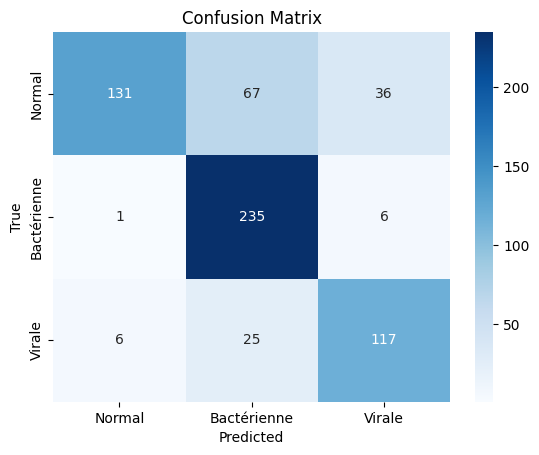

In [12]:
# Prédictions et matrice de confusion
y_pred_prob = model.predict(test_ds)
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Bactérienne', 'Virale']))
cm = confusion_matrix(y_true, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Bactérienne', 'Virale'], yticklabels=['Normal', 'Bactérienne', 'Virale'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 13. Courbe ROC et AUC (one-vs-rest)

Comme on a 3 classes, on trace une courbe ROC par classe en mode « one-vs-rest » (chaque classe contre toutes les autres). L'**AUC** résume la capacité du modèle à séparer une classe des autres (1 = parfait, 0.5 = au hasard). On calcule aussi le **seuil de Youden**, le seuil offrant le meilleur compromis entre vrais positifs et faux positifs.

Seuil optimal Youden pour NORMAL: 0.094
Seuil optimal Youden pour PNEUMONIA_bacterial: 0.637
Seuil optimal Youden pour PNEUMONIA_viral: 0.324


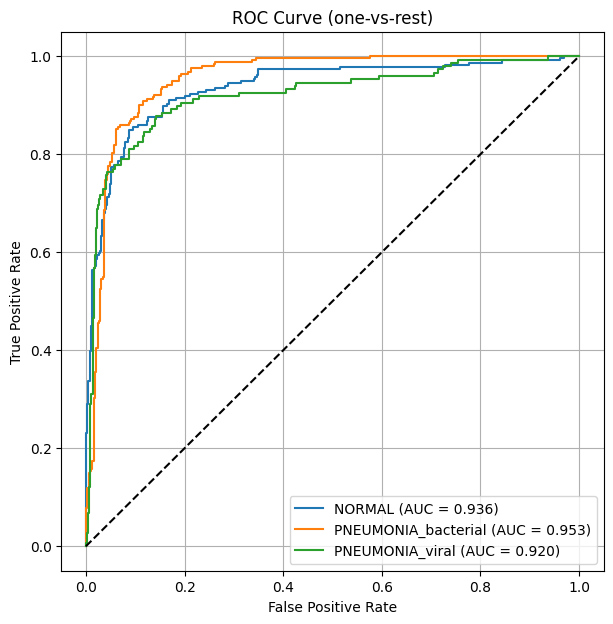

AUC macro : 0.9364439513243088


In [13]:
# ROC one-vs-rest + seuils Youden par classe
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))
plt.figure(figsize=(7, 7))
auc_scores = {}

for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, thresholds = roc_curve(y_true_onehot[:, class_index], y_pred_prob[:, class_index])
    roc_auc = auc(fpr, tpr)
    auc_scores[class_name] = roc_auc
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')
    best_idx = np.argmax(tpr - fpr)
    print(f'Seuil optimal Youden pour {class_name}: {thresholds[best_idx]:.3f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (one-vs-rest)')
plt.legend()
plt.grid()
plt.show()

print('AUC macro :', np.mean(list(auc_scores.values())))

## 14. Recherche de seuils : F1 par classe

On cherche ici, pour chaque classe, le seuil de probabilité qui maximise le **F1-score** (l'équilibre entre précision et rappel), à partir de la courbe précision-rappel. C'est utile car le seuil par défaut de 0.5 n'est pas toujours le meilleur, surtout avec des classes déséquilibrées.

In [14]:
# Seuils F1 par classe (one-vs-rest)
threshold_rows = []
for class_index, class_name in enumerate(CLASS_NAMES):
    precision, recall, thresholds = precision_recall_curve(y_true_onehot[:, class_index], y_pred_prob[:, class_index])
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[min(best_idx, len(thresholds) - 1)]
    threshold_rows.append({
        'class_name': class_name,
        'best_threshold_f1': best_threshold,
        'best_f1': f1_scores[best_idx],
    })
    print(f'Seuil F1 optimal pour {class_name}: {best_threshold:.3f}')

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary

Seuil F1 optimal pour NORMAL: 0.094
Seuil F1 optimal pour PNEUMONIA_bacterial: 0.729
Seuil F1 optimal pour PNEUMONIA_viral: 0.561


,class_name,best_threshold_f1,best_f1
0,NORMAL,0.093595,0.852248
1,PNEUMONIA_bacterial,0.729461,0.874735
2,PNEUMONIA_viral,0.560520,0.804270


## 15. Tableau récapitulatif

On rassemble dans un seul tableau les infos par classe : le nombre d'exemples (support) et les seuils F1 trouvés juste avant. Ça donne une vue d'ensemble plus lisible.

In [15]:
# Table récapitulative des performances par classe
metrics_table = pd.DataFrame({
    'class_name': CLASS_NAMES,
    'support': np.bincount(y_true, minlength=len(CLASS_NAMES)),
})
metrics_table = metrics_table.merge(threshold_summary, on='class_name', how='left')
metrics_table

,class_name,support,best_threshold_f1,best_f1
0,NORMAL,234,0.093595,0.852248
1,PNEUMONIA_bacterial,242,0.729461,0.874735
2,PNEUMONIA_viral,148,0.560520,0.804270


## 16. Balayage de seuils (rappel / faux positifs)

On teste un grand nombre de seuils (1000 valeurs entre 0 et 1) pour chaque classe, en notant à chaque fois le rappel et le taux de faux positifs (FPR). L'idée est de préparer le choix d'un seuil mieux adapté à un usage médical, où on préfère ne pas rater de malade.

In [16]:
# Recherche d’un seuil par classe avec rappel élevé
threshold_grid = np.linspace(0.0, 1.0, 1000)
rows = []

for class_index, class_name in enumerate(CLASS_NAMES):
    positive = y_true_onehot[:, class_index]
    for t in threshold_grid:
        y_pred_binary = (y_pred_prob[:, class_index] >= t).astype(int)
        TN, FP, FN, TP = confusion_matrix(positive, y_pred_binary).ravel()
        recall_cls = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        fpr_cls = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        rows.append({
            'class_name': class_name,
            'threshold': t,
            'recall': recall_cls,
            'fpr': fpr_cls,
            'FN': FN,
            'FP': FP,
        })

threshold_grid_df = pd.DataFrame(rows)
threshold_grid_df.head()

,class_name,threshold,recall,fpr,FN,FP
0,NORMAL,0.000000,1.000000,1.000000,0,390
1,NORMAL,0.001001,0.991453,0.902564,2,352
2,NORMAL,0.002002,0.987179,0.787179,3,307
3,NORMAL,0.003003,0.978632,0.674359,5,263
4,NORMAL,0.004004,0.978632,0.589744,5,230


## 17. Choix d'un seuil « médical »

Pour finir, on cherche pour chaque classe un seuil « médical » : on veut un **rappel d'au moins 95 %** (rater le moins de malades possible) tout en gardant un **taux de faux positifs sous 10 %**. En médecine, un faux négatif (dire « sain » à un malade) est souvent plus grave qu'un faux positif, d'où ce choix. Si aucun seuil ne respecte ces contraintes pour une classe, on le signale.

In [17]:
# Seuil « médical » par classe : meilleur seuil avec rappel élevé et faible FPR
summary_rows = []
for class_name in CLASS_NAMES:
    class_rows = threshold_grid_df[threshold_grid_df['class_name'] == class_name]
    candidates = class_rows[(class_rows['recall'] >= 0.95) & (class_rows['fpr'] <= 0.10)]
    if not candidates.empty:
        best_row = candidates.sort_values(['fpr', 'threshold']).iloc[0]
        summary_rows.append(best_row)
        print(f"{class_name} -> seuil médical: {best_row['threshold']:.3f}")
    else:
        print(f"{class_name} -> aucun seuil ne satisfait les contraintes")

medical_threshold_summary = pd.DataFrame(summary_rows)
medical_threshold_summary

NORMAL -> aucun seuil ne satisfait les contraintes
PNEUMONIA_bacterial -> aucun seuil ne satisfait les contraintes
PNEUMONIA_viral -> aucun seuil ne satisfait les contraintes


""
